# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
data_ab = data_a + data_b

view_a_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_b)
view_ab_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(data_ab)

In [5]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [6]:
view_a_label, _, _ = phenograph.cluster(view_a_feature, random_state=42)
view_b_label, _, _ = phenograph.cluster(view_b_feature, random_state=42)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07061314582824707 seconds
Jaccard graph constructed in 0.16691899299621582 seconds
Wrote graph to binary file in 0.005452632904052734 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.544323
Louvain completed 21 runs in 0.4439079761505127 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.8162591457366943 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0688333511352539 seconds
Jaccard graph constructed in 0.13982081413269043 seconds
Wrote graph to binary file in 0.0048923492431640625 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.682808
Louvain completed 21 runs in 0.4055030345916748 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.739659309387207 seconds
Finding 30 nearest neighbors using minkow

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [7]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_a_feature)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_b_feature)
XY_embedded = TSNE(n_components=2, random_state=42).fit_transform(view_ab_feature)

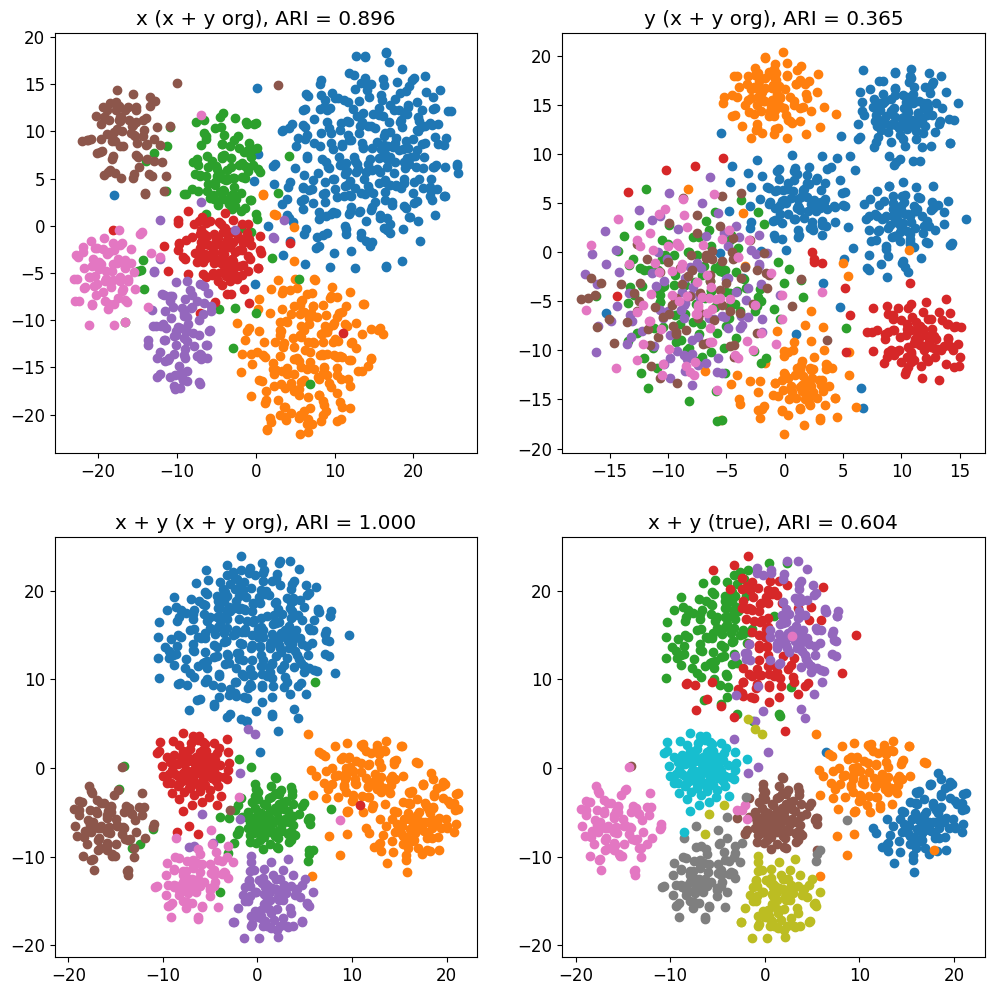

In [8]:
plt.rcParams['font.size'] = 12
plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
# 遍历每一个类别
for i in np.unique(view_ab_label):
    # 找到所有类别为i的索引
    idx = np.nonzero(view_ab_label == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('x (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_a_label))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_b_label))

plt.subplot(2, 2, 3)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, view_ab_label))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(XY_embedded[idx, 0], XY_embedded[idx, 1])
    plt.title('x + y (true), ARI = %01.3f' % adjusted_rand_score(view_ab_label, label_true))
plt.show()

In [62]:
outputs = muse.dual_muse_fit_predict(
    [data_a, data_b],
    [data_ab],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_hidden=128,
    n_epochs=500,
    info_nce_lambda=0,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++


100%|██████████| 15/15 [00:00<00:00, 318.26it/s]


inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: to

100%|██████████| 15/15 [00:00<00:00, 393.05it/s]


inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])


...

  0%|          | 0/15 [00:00<?, ?it/s]

inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])


100%|██████████| 15/15 [00:00<00:00, 494.29it/s]

inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])


inputs: torch.Size([2, 1000, 500])
inputs: torch.Size([1, 1000, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs: torch.Size([2, 64, 500])
inputs: torch.Size([1, 64, 500])
inputs

## Perform clustering
PhenoGraph clustering

In [63]:
latent_sc, latent_st = outputs[0], outputs[1]
muse_label_sc, _, _ = phenograph.cluster(latent_sc, random_state=42)
muse_label_st, _, _ = phenograph.cluster(latent_st, random_state=42)
# 用kmeans聚类
from sklearn.cluster import KMeans
n_clusters = np.unique(view_ab_label).shape[0]
print(f"n_clusters: {n_clusters}")
kmeans_sc = KMeans(n_clusters=n_clusters).fit_predict(latent_sc)
kmeans_st = KMeans(n_clusters=n_clusters).fit_predict(latent_st)


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06721115112304688 seconds
Jaccard graph constructed in 0.5039160251617432 seconds
Wrote graph to binary file in 0.0041539669036865234 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.920044
Louvain completed 21 runs in 0.6877660751342773 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.7248966693878174 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.0680081844329834 seconds
Jaccard graph constructed in 0.4992258548736572 seconds
Wrote graph to binary file in 0.004250526428222656 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.872003
Louvain completed 21 runs in 0.6916022300720215 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.7361159324645996 seconds
n_clusters: 7


In [64]:
reconstruct_sc = (outputs[2])
reconstruct_st = (outputs[3])
encoded_sc = (outputs[4])
encoded_st = (outputs[5])
print(f"latent_sc: {latent_sc.shape}")
print(f"latent_st: {latent_st.shape}")
print(f"reconstruct_sc: {reconstruct_sc.shape}")
print(f"reconstruct_st: {reconstruct_st.shape}")
print(f"encoded_sc: {encoded_sc.shape}")
print(f"encoded_st: {encoded_st.shape}")

latent_sc: (1000, 100)
latent_st: (1000, 100)
reconstruct_sc: (2, 1000, 500)
reconstruct_st: (1, 1000, 500)
encoded_sc: (2, 1000, 128)
encoded_st: (1, 1000, 128)


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

In [65]:
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_sc)
Y_embedded = TSNE(n_components=2, random_state=42).fit_transform(latent_st)

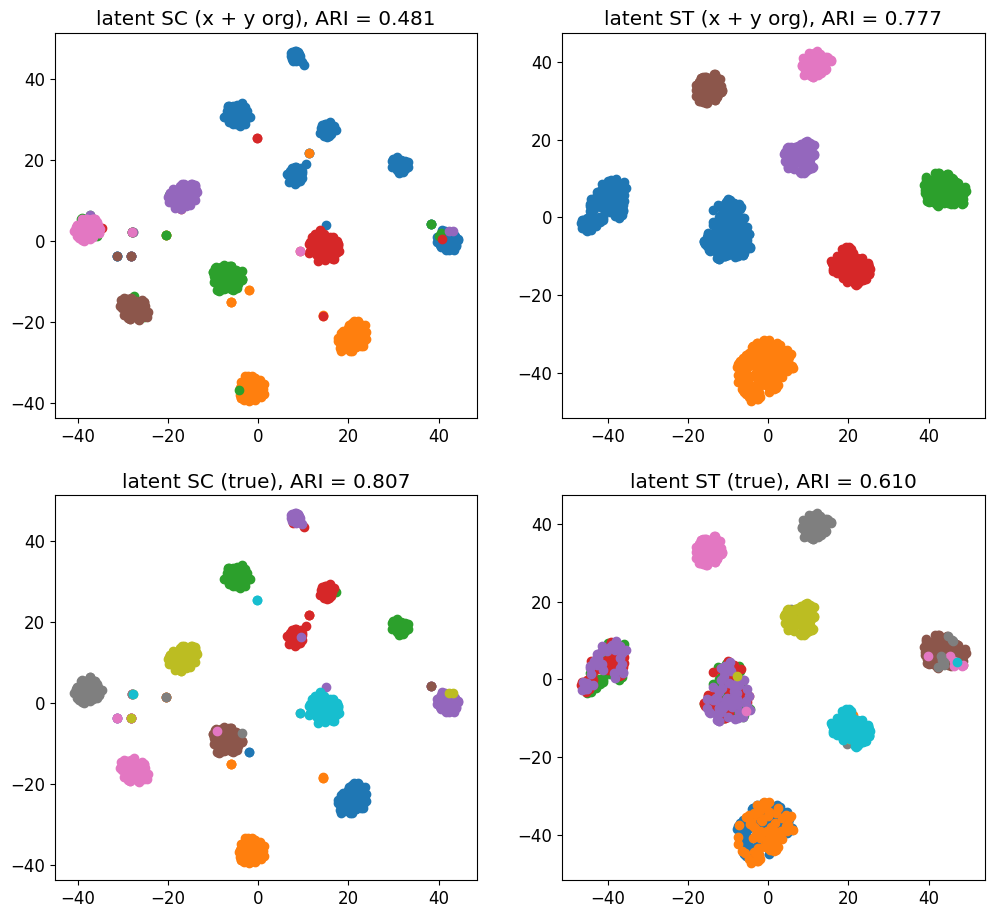

In [66]:
plt.figure(figsize=(12, 11))
plt.subplot(2, 2, 1)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_sc))

plt.subplot(2, 2, 2)
for i in np.unique(view_ab_label):
    idx = np.nonzero(view_ab_label == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (x + y org), ARI = %01.3f' % adjusted_rand_score(view_ab_label, muse_label_st))

plt.subplot(2, 2, 3)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('latent SC (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_sc))

plt.subplot(2, 2, 4)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(Y_embedded[idx, 0], Y_embedded[idx, 1])
    plt.title('latent ST (true), ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_st))

In [67]:
print('phenograph SC and ST ARI: ', adjusted_rand_score(muse_label_sc, muse_label_st))
print('kmeans SC and ST ARI: ', adjusted_rand_score(kmeans_sc, kmeans_st))

phenograph SC and ST ARI:  0.5839622968156802
kmeans SC and ST ARI:  0.3020480252875579


In [68]:
import os
os.makedirs('latent_sc_st', exist_ok=True)
np.save(f'latent_sc_st/latent_sc.npy', latent_sc)
np.save(f'latent_sc_st/latent_st.npy', latent_st)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


 52%|█████▏    | 259/500 [00:00<00:00, 339.80it/s]

100%|██████████| 500/500 [00:01<00:00, 342.12it/s]

Epoch 500: Loss -0.7829540371894836
[[-0.44187614  2.7149806   1.5932266  ... -0.8421626  -1.3670318
   5.1462317 ]
 [ 0.34433794 -1.2840406   0.24168462 ...  1.0459722  -1.0141984
   1.2836993 ]
 [ 0.9813241  -0.1286234  -1.54012    ...  4.289492   -3.6748915
  -1.9104725 ]
 ...
 [ 0.34882838  0.7258433  -3.706097   ... -0.5382712   0.5751613
   0.8800183 ]
 [ 0.42209935  0.8810498  -1.7303185  ... -1.7264633  -2.5084581
   1.7301856 ]
 [ 0.43510774 -0.45529583  0.6775159  ... -2.1621826   0.1985488
   1.8345277 ]]


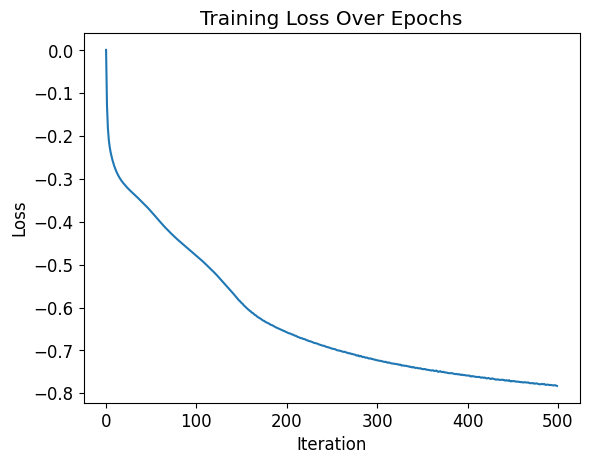

In [69]:
import sim_tangram.train_tangram as tg_cca
import torch

# tangram
tangram_sim, _ = tg_cca.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


100%|██████████| 500/500 [00:00<00:00, 2140.77it/s]

Epoch 500: Loss -0.3361278772354126
[[-0.13617617 -1.5850561   0.46768335 ... -1.2428734  -0.79719895
  -0.61080414]
 [-3.052048    3.8348677  -2.5827863  ... -0.71476364 -1.9249326
  -0.5377486 ]
 [ 1.0046057  -2.6405895  -2.1357784  ...  1.4311335  -3.3942115
  -1.359032  ]
 ...
 [ 0.3255948  -0.28503248 -3.2205417  ... -2.5655267   3.366062
   1.1454034 ]
 [-3.460231   -0.45707318 -3.1775792  ... -2.3281076  -2.963235
   0.16849463]
 [ 1.0190698  -1.8477968  -1.0817702  ... -2.6421385   4.0800495
  -1.8629239 ]]


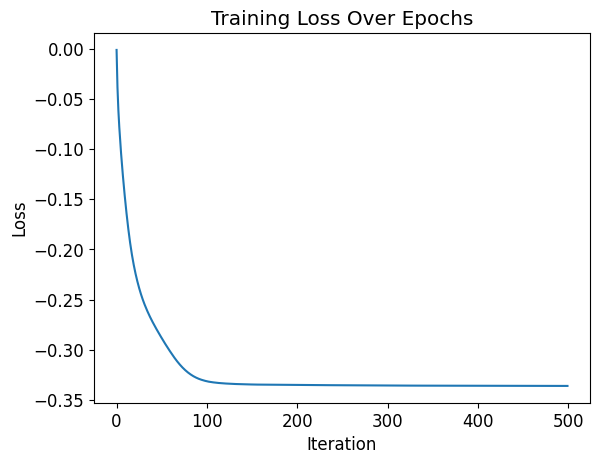

In [70]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(latent_sc, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(latent_st, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [75]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_sim_tg.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
tangram_mapping = tangram_sim.argmax(axis=1)
for i in range(len(tangram_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {tangram_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:  694	 1:  590	 2:  324	 3:  623	 4:  113	
 5:   71	 6:  917	 7:  993	 8:   25	 9:  722	
10:  156	11:  382	12:  357	13:  905	14:   66	
15:  650	16:  904	17:  776	18:  817	19:  386	
20:  589	21:  787	22:  935	23:  829	24:  844	
25:  612	26:  430	27:  307	28:  996	29:  872	
**************************************************

 0:  819	 1:  887	 2:   94	 3:  790	 4:  650	
 5:  573	 6:  226	 7:  214	 8:  409	 9:  916	
10:  914	11:  769	12:  683	13:  746	14:  450	
15:  650	16:  492	17:  829	18:  318	19:  775	
20:  106	21:  117	22:  908	23:  496	24:  123	
25:  489	26:  905	27:  163	28:  566	29:  673	
**************************************************

 0:  449	 1:  746	 2:  891	 3:  462	 4:  650	
 5:   26	 6:  101	 7:  256	 8:  282	 9:  415	
10:  565	11:  245	12:  748	13:  550	14:    4	
15:  650	16:  354	17:  120	18:  269	19:  775	
20:  328	21:  745	22:  557	23:  788	24:  756	
25:  590	26:  216	27:  163	28:  706	29:  171	
**************************************************


In [72]:
# 计算acc
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(tangram_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)


cos accuracy: 0.002
tangram accuracy: 0.001
cos_tg accuracy: 0.001


**************************************************
S: torch.Size([1000, 500, 1])
G: torch.Size([1000, 500, 1])


 35%|███▌      | 177/500 [00:00<00:00, 1763.71it/s]

100%|██████████| 500/500 [00:00<00:00, 1991.42it/s]


Epoch 500: Loss -1.5473058223724365
[[-0.564258   -0.9260446  -2.097289   ... -2.4311152  -2.1469975
  -2.13361   ]
 [-3.6943583  -3.849877    4.6558137  ...  1.1900822  -3.1769526
  -1.3713307 ]
 [-0.61053145  7.3580227  -2.6177392  ... -2.1132257  -3.043385
  -2.6432397 ]
 ...
 [-1.7574772  -2.206298   -3.7844055  ... -1.291983    1.4130995
   5.7739196 ]
 [ 4.903924   -2.486126   -2.9937224  ... -1.9102725  -3.1705523
  -0.08093428]
 [-2.2655656   6.3185573  -1.7102257  ...  5.4022613  -0.20435727
   5.54507   ]]


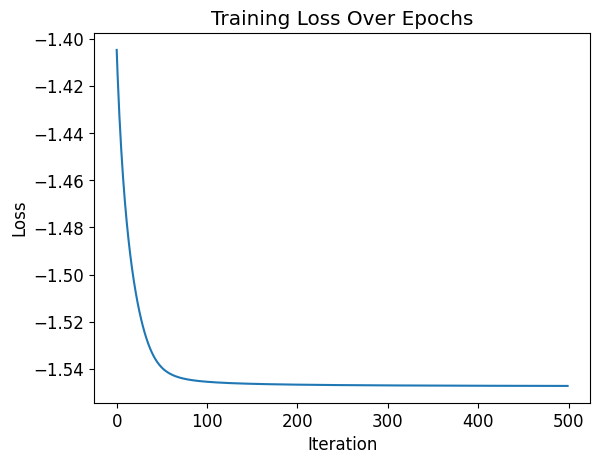

In [73]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
org_mapping, _ = tg_cos.read_csv_and_run_tangram(
    [torch.tensor(data_a, device='cuda:0', dtype=torch.float32)],
    [torch.tensor(data_b, device='cuda:0', dtype=torch.float32)],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [74]:
# 检验cosine_similarity驱动的tangram
cos_tg_mapping = org_mapping.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size
print("cos_tg accuracy:", cos_tg_acc)


 0:  391	 1:   44	 2:  993	 3:  496	 4:  609	
 5:  640	 6:  319	 7:  704	 8:  283	 9:  905	
10:  746	11:  931	12:  334	13:  391	14:  349	
15:  607	16:  732	17:  188	18:  186	19:  313	
20:  171	21:  681	22:   69	23:  571	24:  508	
25:  184	26:  598	27:  467	28:  474	29:  766	
**************************************************
cos_tg accuracy: 0.004
